# TP N°2 - Umbralización / Binarización

**Fundamentos del Procesamiento Digital de Imágenes**

Objetivo del bloque: segmentar un objeto de color distintivo (una **amapola roja** sobre follaje verde) y comparar dos dominios de trabajo:

1. **Escala de grises (luminancia)**: umbral binario, a zero, Otsu y sus variantes invertidas.
2. **Espacio HSV**: umbral sobre el canal H (matiz), refinado con S y V.

**Imagen:** [*Poppy flower 02*](https://commons.wikimedia.org/wiki/File:Poppy_flower_02.jpg), de Nayan j Nath, Wikimedia Commons, licencia **CC0** (dominio público). Se usa la versión de 1280x853 px.

Es un caso elegido a propósito: el rojo de los pétalos y el verde del follaje son colores opuestos en el círculo cromático, pero al pasarlos a luminancia quedan en **grises parecidos** (el clásico par rojo/verde que se confunde en blanco y negro). Es decir: separación trivial por color y muy difícil por brillo.

**Criterio de evaluación.** Para no depender sólo de "se ve bien", se usa una **máscara de referencia (ground truth) aproximada**: un polígono dibujado a mano sobre el contorno de la flor. Se define por geometría, no por color, así se evita el razonamiento circular de "etiquetar por color y después descubrir que el color separa bien" (misma idea que en el notebook *Espacios de Color: Criterio Empírico*). Con ella se calculan:

* **IoU** (Intersection over Union) entre la máscara obtenida y la referencia: 1 = coincidencia perfecta.
* **Precisión** (qué fracción de lo segmentado es flor) y **exhaustividad / recall** (qué fracción de la flor se segmentó).
* **Coeficiente de solapamiento** y **razón de Fisher** entre los histogramas objeto / fondo de cada canal, para medir *antes de umbralizar* qué tan separable es el objeto en cada dominio.

> El polígono (141 vértices) se trazó a mano siguiendo el borde de los pétalos. Aun así ninguna máscara llega a IoU = 1: el borde tiene píxeles mezclados flor/fondo y la referencia incluye el centro de la flor, que no es rojo. Sirve para **comparar** métodos entre sí, no como valor absoluto.

## 0. Configuración

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

import ipywidgets as widgets
from ipywidgets import interactive
from IPython.display import display

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['image.interpolation'] = 'nearest'

**Descarga de la imagen.** Se baja desde Wikimedia Commons con Python (no con `wget`) para poder **verificar** que lo descargado sea realmente una imagen: si el servidor responde con una página de error, `wget` la guarda igual con nombre `.jpg` y el error recién aparece después, en `cvtColor`. Se prueban dos URLs (la versión de 1280 px y el original) y, si ambas fallan, en Colab se ofrece subir el archivo a mano desde la [página de la imagen](https://commons.wikimedia.org/wiki/File:Poppy_flower_02.jpg).

In [ ]:
import os
import urllib.request

RUTA_IMAGEN = 'amapola.jpg'
URLS_IMAGEN = [
    # Versión de 1280 px de ancho: es la que se usó para trazar GT_POLIGONO
    'https://upload.wikimedia.org/wikipedia/commons/thumb/3/38/Poppy_flower_02.jpg/1280px-Poppy_flower_02.jpg',
    # Original en resolución completa (6000x4000): se reescala a 1280 px al cargarla
    'https://upload.wikimedia.org/wikipedia/commons/3/38/Poppy_flower_02.jpg',
]
# Wikimedia pide un User-Agent descriptivo; con uno genérico puede responder 403
HEADERS = {'User-Agent': 'TP-PDI/1.0 (trabajo practico universitario de procesamiento de imagenes)'}


def es_imagen_valida(ruta):
    return os.path.exists(ruta) and cv2.imread(ruta) is not None


def descargar_imagen(ruta, urls):
    for url in urls:
        try:
            pedido = urllib.request.Request(url, headers=HEADERS)
            with urllib.request.urlopen(pedido, timeout=120) as respuesta:
                datos = respuesta.read()
            with open(ruta, 'wb') as archivo:
                archivo.write(datos)
            if es_imagen_valida(ruta):
                print(f"Descargada desde {url} ({len(datos) / 1024:.0f} KB)")
                return True
            print(f"La respuesta de {url} no es una imagen válida ({len(datos)} bytes)")
        except Exception as e:
            print(f"Falló la descarga desde {url}: {e}")
    return False


if es_imagen_valida(RUTA_IMAGEN):
    print(f"'{RUTA_IMAGEN}' ya existe y es válida, no se descarga de nuevo")
elif not descargar_imagen(RUTA_IMAGEN, URLS_IMAGEN):
    try:
        from google.colab import files
        print("No se pudo descargar. Subir la imagen a mano (bajada desde "
              "https://commons.wikimedia.org/wiki/File:Poppy_flower_02.jpg):")
        subidos = files.upload()
        with open(RUTA_IMAGEN, 'wb') as archivo:
            archivo.write(next(iter(subidos.values())))
    except ImportError:
        print(f"Fuera de Colab: copiar la imagen manualmente como '{RUTA_IMAGEN}' junto al notebook")

Descargada desde https://upload.wikimedia.org/wikipedia/commons/thumb/3/38/Poppy_flower_02.jpg/1280px-Poppy_flower_02.jpg (179 KB)


In [ ]:
img_bgr = cv2.imread(RUTA_IMAGEN)            # OpenCV carga en BGR
if img_bgr is None:
    raise FileNotFoundError(f"No se pudo leer '{RUTA_IMAGEN}': revisar la celda de descarga")

# GT_POLIGONO está en coordenadas de la versión de 1280 px de ancho: si se obtuvo otra resolución, se reescala
ANCHO_REFERENCIA = 1280
if img_bgr.shape[1] != ANCHO_REFERENCIA:
    escala = ANCHO_REFERENCIA / img_bgr.shape[1]
    nuevo_tamano = (ANCHO_REFERENCIA, round(img_bgr.shape[0] * escala))
    print(f"Reescalando de {img_bgr.shape[1]}x{img_bgr.shape[0]} a {nuevo_tamano[0]}x{nuevo_tamano[1]}")
    img_bgr = cv2.resize(img_bgr, nuevo_tamano, interpolation=cv2.INTER_AREA)

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
alto, ancho = img_rgb.shape[:2]
print(f"Imagen: {ancho}x{alto} px, dtype={img_rgb.dtype}")

Imagen: 1280x853 px, dtype=uint8


### 0.1. Máscara de referencia y métricas

El polígono se dibujó a mano para esta imagen (1280x853). **Si se cambia de imagen hay que redefinir `GT_POLIGONO`.**

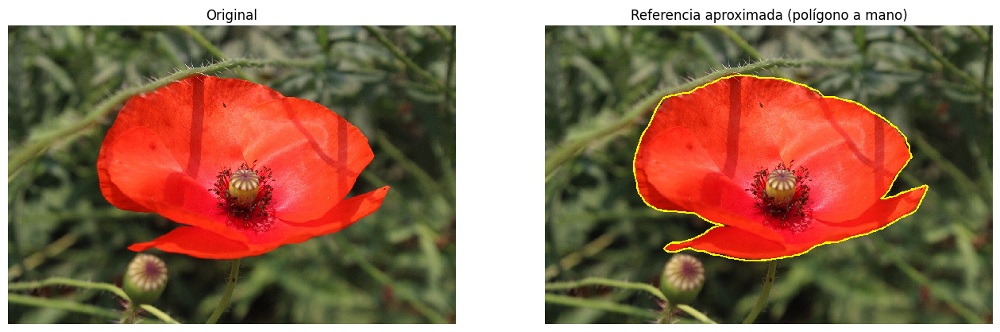

In [ ]:
GT_POLIGONO = np.array([(254, 393), (255, 418), (262, 449), (263, 462), (268, 479), (279, 492), (285, 503), (298, 514),
                        (303, 515), (318, 524), (341, 529), (400, 533), (406, 535), (426, 535), (452, 551), (473, 561),
                        (491, 567), (496, 567), (510, 571), (491, 573), (481, 576), (467, 584), (454, 595), (418, 611),
                        (383, 620), (363, 620), (350, 627), (340, 636), (340, 638), (343, 641), (353, 646), (374, 646),
                        (401, 637), (416, 636), (429, 642), (457, 645), (474, 652), (489, 656), (498, 656), (530, 664),
                        (576, 671), (609, 671), (641, 669), (652, 666), (670, 665), (684, 661), (704, 659), (717, 655),
                        (724, 655), (750, 645), (756, 639), (776, 628), (789, 626), (802, 620), (834, 619), (881, 603),
                        (887, 603), (899, 599), (919, 596), (938, 587), (942, 587), (956, 581), (965, 579), (1020, 547),
                        (1041, 539), (1056, 531), (1060, 527), (1072, 507), (1075, 498), (1081, 489), (1093, 462), (1093, 459),
                        (1088, 456), (1070, 463), (1062, 464), (1052, 468), (1047, 468), (1040, 472), (1018, 478), (999, 488),
                        (983, 490), (974, 494), (960, 493), (967, 489), (983, 471), (994, 448), (1011, 420), (1033, 395),
                        (1035, 390), (1047, 376), (1046, 368), (1042, 362), (1042, 346), (1034, 334), (1031, 322), (1026, 314),
                        (1009, 298), (1004, 291), (994, 286), (978, 272), (953, 256), (932, 246), (908, 229), (881, 217),
                        (866, 215), (837, 208), (823, 203), (795, 203), (792, 198), (780, 187), (760, 180), (740, 170),
                        (720, 166), (694, 156), (689, 156), (676, 152), (640, 149), (611, 149), (601, 144), (590, 144),
                        (585, 142), (543, 143), (531, 145), (525, 148), (504, 150), (476, 165), (464, 167), (449, 176),
                        (437, 177), (416, 190), (410, 192), (386, 194), (367, 200), (361, 200), (343, 205), (337, 209),
                        (318, 238), (296, 287), (283, 304), (276, 317), (259, 368)], np.int32)

gt = np.zeros((alto, ancho), np.uint8)
cv2.fillPoly(gt, [GT_POLIGONO], 1)
gt = gt.astype(bool)


def metricas(mascara, referencia=gt):
    """IoU, precisión y recall de una máscara binaria contra la referencia."""
    m = mascara.astype(bool)
    tp = np.sum(m & referencia)
    fp = np.sum(m & ~referencia)
    fn = np.sum(~m & referencia)
    return {'IoU': tp / (tp + fp + fn + 1e-9),
            'precision': tp / (tp + fp + 1e-9),
            'recall': tp / (tp + fn + 1e-9)}


def texto_metricas(mascara):
    r = metricas(mascara)
    return f"IoU={r['IoU']:.3f} | P={r['precision']:.2f} | R={r['recall']:.2f}"


def superponer(img, mascara, color=(0, 255, 255), alfa=0.5):
    """Pinta la máscara semitransparente (cian, complementario del rojo) sobre la imagen RGB."""
    salida = img.copy()
    capa = np.zeros_like(img)
    capa[mascara.astype(bool)] = color
    m = mascara.astype(bool)
    salida[m] = cv2.addWeighted(img, 1 - alfa, capa, alfa, 0)[m]
    return salida


def coef_solapamiento(canal, rango, bins=64, referencia=gt):
    """Masa de probabilidad compartida entre los histogramas de objeto y fondo (0 = separables, 1 = idénticos)."""
    h_obj, _ = np.histogram(canal[referencia], bins=bins, range=rango)
    h_fon, _ = np.histogram(canal[~referencia], bins=bins, range=rango)
    return np.minimum(h_obj / h_obj.sum(), h_fon / h_fon.sum()).sum()


def razon_fisher(canal, referencia=gt):
    """(mu_obj - mu_fondo)^2 / (var_obj + var_fondo). Mayor = mejor separación."""
    x = canal.astype(np.float64)
    return (x[referencia].mean() - x[~referencia].mean()) ** 2 / (x[referencia].var() + x[~referencia].var())


# Verificación visual de la referencia
img_con_gt = img_rgb.copy()
cv2.polylines(img_con_gt, [GT_POLIGONO], True, (255, 255, 0), 3)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
axes[0].imshow(img_rgb); axes[0].set_title("Original")
axes[1].imshow(img_con_gt); axes[1].set_title("Referencia aproximada (polígono a mano)")
for ax in axes: ax.axis('off')
plt.show()

## 1. Enfoque en escala de grises (luminancia)

Se convierte con `cv2.COLOR_RGB2GRAY`, que calcula la luminancia perceptual `Y = 0.299 R + 0.587 G + 0.114 B` (la misma Y de YIQ / YCbCr).

### 1.1. Diagnóstico previo: ¿el objeto es separable por brillo?

Antes de mover sliders conviene mirar el histograma **separado en objeto y fondo** (usando la referencia). Si los dos histogramas se solapan, *ningún* umbral global va a funcionar bien, y eso se sabe antes de probar.

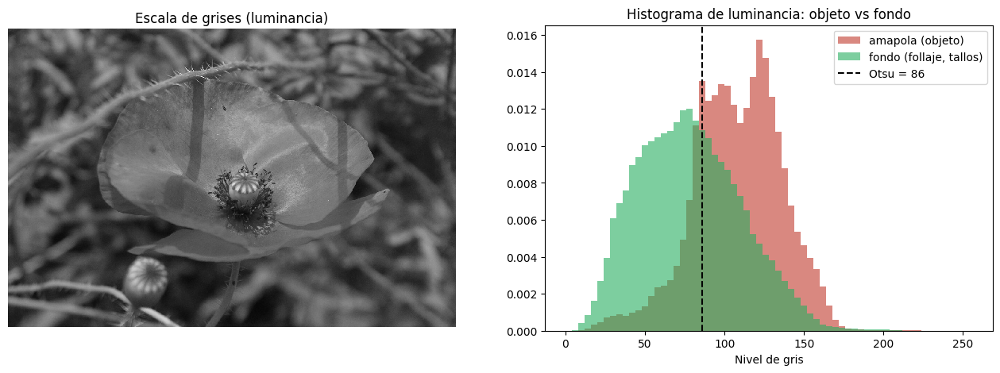

Coeficiente de solapamiento (gris): 0.585
Razón de Fisher (gris):             0.511


In [ ]:
img_gris = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
umbral_otsu, _ = cv2.threshold(img_gris, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].imshow(img_gris, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Escala de grises (luminancia)"); axes[0].axis('off')

axes[1].hist(img_gris[gt], bins=64, range=(0, 256), density=True, alpha=0.6, color='#c0392b', label='amapola (objeto)')
axes[1].hist(img_gris[~gt], bins=64, range=(0, 256), density=True, alpha=0.6, color='#27ae60', label='fondo (follaje, tallos)')
axes[1].axvline(umbral_otsu, color='k', ls='--', label=f'Otsu = {umbral_otsu:.0f}')
axes[1].set_title("Histograma de luminancia: objeto vs fondo")
axes[1].set_xlabel("Nivel de gris"); axes[1].legend()
plt.show()

print(f"Coeficiente de solapamiento (gris): {coef_solapamiento(img_gris, (0, 256)):.3f}")
print(f"Razón de Fisher (gris):             {razon_fisher(img_gris):.3f}")

**Lectura.** En gris la flor "desaparece": un rojo saturado (R alto, G y B bajos) tiene una luminancia media, porque R pesa sólo 0.299 en Y, y queda en la misma zona del histograma que las hojas verdes iluminadas. La flor es en promedio algo más clara que el fondo (mediana ~109 contra ~76), pero los dos histogramas comparten **alrededor del 58 % de su masa**: no hay un valle entre ellos. Las sombras sobre los pétalos (la del tallo, los pliegues) bajan todavía más la luminancia de partes de la flor.

### 1.2. Umbralización interactiva

Tipos de umbral de OpenCV (`cv2.threshold(src, umbral, maxval, tipo)`):

| Tipo | Resultado | Máscara usada para la métrica |
|---|---|---|
| Binario | `maxval` si `p > umbral`, `0` si no | `p > umbral` |
| Binario Invertido | `0` si `p > umbral`, `maxval` si no | `p <= umbral` |
| A Zero | `p` si `p > umbral`, `0` si no (conserva intensidades) | `p > umbral` |
| A Zero Invertido | `0` si `p > umbral`, `p` si no | `p <= umbral` |
| Otsu / Otsu Invertido | Igual que binario, pero el umbral lo calcula Otsu (ignora el slider) | idem |
| Banda (`inRange`) | `maxval` si `a <= p <= b` | doble umbral |

`THRESH_TRUNC` no se incluye porque no separa nada (sólo recorta los valores altos): no produce una máscara.

Notar que "A Zero" genera **la misma máscara** que "Binario" con el mismo umbral; la diferencia es que no binariza, deja el valor original del píxel. Eso es útil cuando después se quiere seguir procesando el objeto (por ejemplo, el bloque de paletas del TP pide justamente umbralizar *sin binarizar*).

In [ ]:
BANDA = -1  # código propio para el umbral por banda (doble umbral)

TIPOS_UMBRAL = [('Binario', cv2.THRESH_BINARY),
                ('Binario Invertido', cv2.THRESH_BINARY_INV),
                ('A Zero', cv2.THRESH_TOZERO),
                ('A Zero Invertido', cv2.THRESH_TOZERO_INV),
                ('Otsu', cv2.THRESH_BINARY + cv2.THRESH_OTSU),
                ('Otsu Invertido', cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU),
                ('Banda (inRange)', BANDA)]


def umbralizar_gris(img, umbral, valor_max, tipo, banda=(0, 255)):
    """Devuelve (umbral_usado, imagen_resultado, mascara_bool)."""
    if tipo == BANDA:
        res = cv2.inRange(img, banda[0], banda[1])
        res = (res > 0).astype(np.uint8) * valor_max
        return banda, res, res > 0
    t, res = cv2.threshold(img, umbral, valor_max, tipo)
    # Para A Zero la máscara no es "res > 0" en general (un píxel de valor 0 que pasa el umbral seguiría en 0),
    # así que se reconstruye la máscara a partir del umbral efectivo.
    invertido = tipo in (cv2.THRESH_BINARY_INV, cv2.THRESH_TOZERO_INV, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    mascara = (img <= t) if invertido else (img > t)
    return t, res, mascara


def plot_umbral_gris(umbral, valor_max, tipo, banda):
    t, res, mascara = umbralizar_gris(img_gris, umbral, valor_max, tipo, banda)
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    axes[0].imshow(img_gris, cmap='gray', vmin=0, vmax=255); axes[0].set_title("Escala de grises")
    axes[1].imshow(res, cmap='gray', vmin=0, vmax=255); axes[1].set_title(f"Resultado (umbral efectivo = {t})")
    axes[2].imshow(superponer(img_rgb, mascara)); axes[2].set_title(texto_metricas(mascara))
    for ax in axes: ax.axis('off')
    plt.show()


umbral_slider = widgets.IntSlider(value=81, min=0, max=255, step=1, description='Umbral')
max_slider = widgets.IntSlider(value=255, min=1, max=255, step=1, description='Máximo')
tipo_select = widgets.Dropdown(options=TIPOS_UMBRAL, value=cv2.THRESH_BINARY, description='Tipo')
banda_slider = widgets.IntRangeSlider(value=[80, 175], min=0, max=255, step=1, description='Banda')

interactive_gris = interactive(plot_umbral_gris, umbral=umbral_slider, valor_max=max_slider,
                               tipo=tipo_select, banda=banda_slider)
interactive_gris.children[-1].layout.height = '450px'
display(interactive_gris)

interactive(children=(IntSlider(value=81, description='Umbral', max=255), IntSlider(value=255, description='Má…

**Qué se observa al mover los sliders** (bitácora del ensayo interactivo):

* **Binario** (objeto = claro): es el sentido correcto, porque la flor es algo más clara que el fondo. Pero no hay ningún valor que funcione: con umbral alto (130) queda sólo la zona más iluminada del centro de los pétalos (la mayor parte de la flor queda afuera) y ya entran algunas hojas al sol; al bajarlo (80) la flor se completa, salvo la franja de sombra del tallo y los bordes, pero al mismo tiempo entran los tallos, el capullo y una buena parte del follaje desenfocado.
* **Binario Invertido** (objeto = oscuro): segmenta el follaje en sombra. Es el sentido equivocado.
* **Otsu**: elige un umbral ≈ 86, casi el mismo que el mejor posible (≈ 81), y da un resultado igual de malo. Otsu hace lo que promete (separa los dos modos del histograma), pero los modos que encuentra son "zonas oscuras vs zonas claras de la escena", no "flor vs fondo".
* **A Zero / A Zero Invertido**: misma máscara que binario / binario invertido; sólo cambia que conserva los grises.
* **Banda**: acotar también por arriba no ayuda, porque las hojas iluminadas caen en el mismo rango que los pétalos.


### 1.3. ¿Cuál es el *mejor* umbral global posible en grises?

En lugar de quedarse con la impresión visual, se barren **todos** los umbrales y se mide el IoU contra la referencia. Es un "oráculo": usa la respuesta correcta para elegir el umbral, así que es una **cota superior** de lo que puede lograr cualquier umbral global en este dominio.

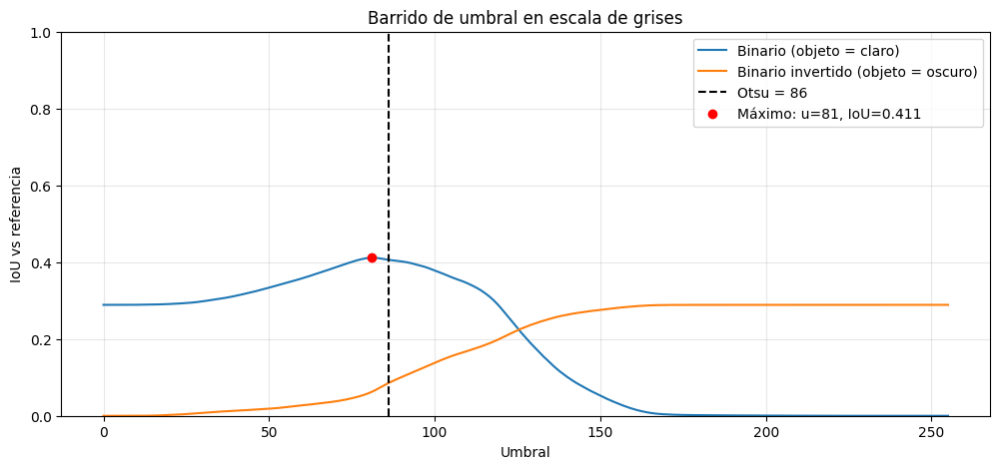

Mejor binario:            u= 81  IoU=0.411
Mejor binario invertido:  u=230  IoU=0.289
Otsu:                     u=86  IoU=0.406 | invertido IoU=0.085
Mejor banda:              [80, 175]  IoU=0.410


In [ ]:
umbrales = np.arange(256)
iou_bin = [metricas(img_gris > u)['IoU'] for u in umbrales]
iou_inv = [metricas(img_gris <= u)['IoU'] for u in umbrales]

mejor_bin = int(np.argmax(iou_bin))
mejor_inv = int(np.argmax(iou_inv))

# Sentido ganador: el que logra mayor IoU máximo
OBJETO_CLARO = iou_bin[mejor_bin] >= iou_inv[mejor_inv]
UMBRAL_GRIS_FIJO = mejor_bin if OBJETO_CLARO else mejor_inv

plt.figure(figsize=(12, 5))
plt.plot(umbrales, iou_bin, label='Binario (objeto = claro)')
plt.plot(umbrales, iou_inv, label='Binario invertido (objeto = oscuro)')
plt.axvline(umbral_otsu, color='k', ls='--', label=f'Otsu = {umbral_otsu:.0f}')
mejor_iou = max(iou_bin[mejor_bin], iou_inv[mejor_inv])
plt.scatter([UMBRAL_GRIS_FIJO], [mejor_iou], color='r', zorder=5, label=f'Máximo: u={UMBRAL_GRIS_FIJO}, IoU={mejor_iou:.3f}')
plt.xlabel('Umbral'); plt.ylabel('IoU vs referencia'); plt.ylim(0, 1)
plt.title('Barrido de umbral en escala de grises'); plt.legend(); plt.grid(alpha=0.3)
plt.show()

print(f"Mejor binario:            u={mejor_bin:3d}  IoU={iou_bin[mejor_bin]:.3f}")
print(f"Mejor binario invertido:  u={mejor_inv:3d}  IoU={iou_inv[mejor_inv]:.3f}")
print(f"Otsu:                     u={umbral_otsu:.0f}  IoU={metricas(img_gris > umbral_otsu)['IoU']:.3f} | "
      f"invertido IoU={metricas(img_gris <= umbral_otsu)['IoU']:.3f}")

# Banda: barrido grueso de [a, b]
mejor_banda = max(((metricas((img_gris >= a) & (img_gris <= b))['IoU'], a, b)
                   for a in range(0, 256, 5) for b in range(a + 5, 256, 5)))
print(f"Mejor banda:              [{mejor_banda[1]}, {mejor_banda[2]}]  IoU={mejor_banda[0]:.3f}")

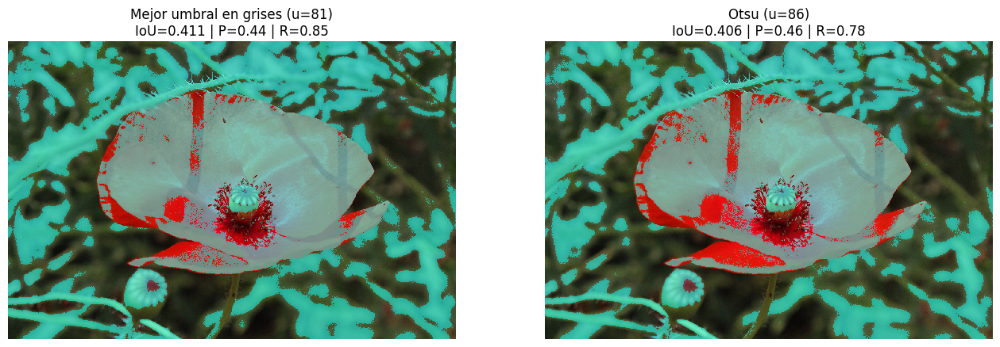

In [ ]:
def seg_gris_fijo(img):
    g = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return g > UMBRAL_GRIS_FIJO if OBJETO_CLARO else g <= UMBRAL_GRIS_FIJO


mascara_gris_mejor = seg_gris_fijo(img_rgb)
mascara_gris_otsu = img_gris > umbral_otsu

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
axes[0].imshow(superponer(img_rgb, mascara_gris_mejor))
axes[0].set_title(f"Mejor umbral en grises (u={UMBRAL_GRIS_FIJO})\n{texto_metricas(mascara_gris_mejor)}")
axes[1].imshow(superponer(img_rgb, mascara_gris_otsu))
axes[1].set_title(f"Otsu (u={umbral_otsu:.0f})\n{texto_metricas(mascara_gris_otsu)}")
for ax in axes: ax.axis('off')
plt.show()

### 1.4. **Conclusión del enfoque en grises.**
Aun eligiendo el umbral con el oráculo, el IoU no pasa de **≈ 0.41** (precisión muy baja, ≈ 0.44: más de la mitad de lo segmentado es follaje). La curva es achatada y no tiene un máximo marcado: no es un problema de elegir mal el umbral ni el tipo. **La información para separar no está en la luminancia.** Otsu cae prácticamente en el mismo punto que el oráculo, lo que confirma que el límite es del dominio, no del método.


## 2. Enfoque en espacio HSV



### 2.1. Visualización de los canales (y la elección de la paleta)

Acá la **paleta importa**. El canal H es un **ángulo**: en OpenCV va de 0 a 179 (= 0° a 358°) y el rojo está justo en el empalme, H ≈ 0 **y** H ≈ 179. Si se lo muestra con `gray`, dos píxeles rojos casi idénticos (H=1 y H=178) se ven uno negro y otro blanco: la paleta *inventa* un borde que no existe en el color. Con una paleta **cíclica** (`hsv`, `twilight`), ambos extremos tienen el mismo color y la flor se ve como una región homogénea.

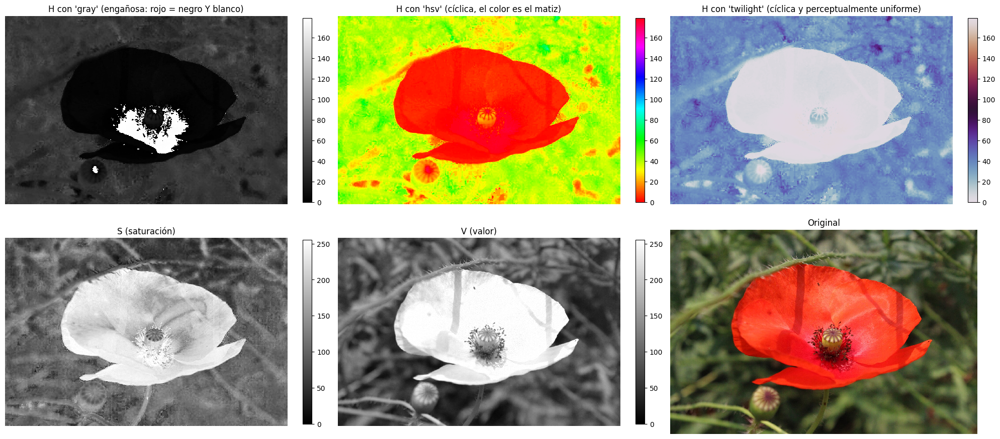

In [ ]:
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
canal_h, canal_s, canal_v = cv2.split(img_hsv)

fig, axes = plt.subplots(2, 3, figsize=(20, 9))
im = axes[0, 0].imshow(canal_h, cmap='gray', vmin=0, vmax=179); axes[0, 0].set_title("H con 'gray' (engañosa: rojo = negro Y blanco)")
fig.colorbar(im, ax=axes[0, 0], fraction=0.03)
im = axes[0, 1].imshow(canal_h, cmap='hsv', vmin=0, vmax=179); axes[0, 1].set_title("H con 'hsv' (cíclica, el color es el matiz)")
fig.colorbar(im, ax=axes[0, 1], fraction=0.03)
im = axes[0, 2].imshow(canal_h, cmap='twilight', vmin=0, vmax=179); axes[0, 2].set_title("H con 'twilight' (cíclica y perceptualmente uniforme)")
fig.colorbar(im, ax=axes[0, 2], fraction=0.03)
im = axes[1, 0].imshow(canal_s, cmap='gray', vmin=0, vmax=255); axes[1, 0].set_title("S (saturación)")
fig.colorbar(im, ax=axes[1, 0], fraction=0.03)
im = axes[1, 1].imshow(canal_v, cmap='gray', vmin=0, vmax=255); axes[1, 1].set_title("V (valor)")
fig.colorbar(im, ax=axes[1, 1], fraction=0.03)
axes[1, 2].imshow(img_rgb); axes[1, 2].set_title("Original")
for ax in axes.ravel(): ax.axis('off')
plt.tight_layout(); plt.show()

Para umbralizar el rojo sin pelear con el empalme 0/179, en lugar de dos rangos (`[0, a]` ∪ `[b, 179]`) se usa la **distancia angular al matiz de interés**:

$$d(H, H_c) = \min(|H - H_c|,\ 180 - |H - H_c|)$$

Así el umbral es un único parámetro ("ancho" alrededor del centro), funciona igual para cualquier color y respeta la circularidad. Visualizar $d$ con una paleta secuencial perceptualmente uniforme (`viridis`) ayuda a elegir el ancho: la flor aparece como una región uniforme de valor bajo.

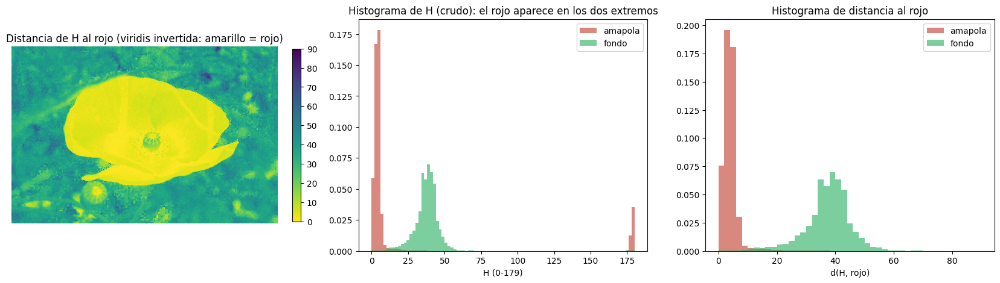

Solapamiento - gris: 0.585 | d(H, rojo): 0.029
Fisher       - gris: 0.511 | H crudo (ingenuo, ignora circularidad): 0.096 | d(H, rojo): 15.82


In [ ]:
def distancia_matiz(h, centro):
    """Distancia angular (en unidades de OpenCV, 0-90) entre cada H y el matiz centro."""
    d = np.abs(h.astype(np.int16) - int(centro))
    return np.minimum(d, 180 - d).astype(np.uint8)


dist_rojo = distancia_matiz(canal_h, 0)

fig, axes = plt.subplots(1, 3, figsize=(21, 5))
im = axes[0].imshow(dist_rojo, cmap='viridis_r', vmin=0, vmax=90)
axes[0].set_title("Distancia de H al rojo (viridis invertida: amarillo = rojo)"); axes[0].axis('off')
fig.colorbar(im, ax=axes[0], fraction=0.03)

axes[1].hist(canal_h[gt], bins=90, range=(0, 180), density=True, alpha=0.6, color='#c0392b', label='amapola')
axes[1].hist(canal_h[~gt], bins=90, range=(0, 180), density=True, alpha=0.6, color='#27ae60', label='fondo')
axes[1].set_title("Histograma de H (crudo): el rojo aparece en los dos extremos"); axes[1].set_xlabel("H (0-179)"); axes[1].legend()

axes[2].hist(dist_rojo[gt], bins=45, range=(0, 90), density=True, alpha=0.6, color='#c0392b', label='amapola')
axes[2].hist(dist_rojo[~gt], bins=45, range=(0, 90), density=True, alpha=0.6, color='#27ae60', label='fondo')
axes[2].set_title("Histograma de distancia al rojo"); axes[2].set_xlabel("d(H, rojo)"); axes[2].legend()
plt.show()

print(f"Solapamiento - gris: {coef_solapamiento(img_gris, (0, 256)):.3f} | "
      f"d(H, rojo): {coef_solapamiento(dist_rojo, (0, 90), bins=45):.3f}")
print(f"Fisher       - gris: {razon_fisher(img_gris):.3f} | "
      f"H crudo (ingenuo, ignora circularidad): {razon_fisher(canal_h):.3f} | d(H, rojo): {razon_fisher(dist_rojo):.2f}")

El histograma de H ya muestra la diferencia: la flor se concentra en H ∈ [0, 5] ∪ [177, 179] y el follaje en H ≈ 30-50 (verde amarillento). El solapamiento cae de ~0.58 (gris) a ~0.03. Notar también que la razón de Fisher calculada **ingenuamente sobre H crudo** da casi cero (≈ 0.10, peor que el gris): la media y la varianza no tienen sentido en una variable circular. Con la distancia angular, Fisher pasa de ≈ 0.51 (gris) a ≈ 16: unas 30 veces mayor.

### 2.1.1. Solapamiento frente a separación: histograma y nubes de píxeles

El solapamiento resume en un número cuánto se mezclan las clases; los gráficos siguientes permiten verlo, con la flor en **rojo** y el fondo en **verde** (según la referencia).

* **a) Gris.** $Y$ es un solo número por píxel, así que alcanza con superponer los histogramas de luminancia de la flor y del fondo, normalizados (cada uno suma 1) porque la flor ocupa menos área que el fondo. La línea es el mejor umbral posible (sección 1.3).
* **b) Rueda de matices.** Nube de píxeles: cada punto es un píxel, ubicado por su ángulo H (en grados reales, el doble del valor de OpenCV) y por su saturación S como distancia al centro. Es la forma natural de mirar H: el rojo de 2° y el de 354° quedan juntos, como en el color real. El sector sombreado es la región que acepta la máscara de HSV con los valores elegidos en la sección 2.2 (ancho 10, S ≥ 100).
* **c) Distancia al rojo y saturación.** Lo mismo "desenrollado": $d(H, \text{rojo})$ en el eje horizontal y S en el vertical, con la misma región sombreada.

En las nubes (b y c), si los grupos se superponen ningún umbral los separa; si quedan apartados, el umbral es una región entre ellos. Para que la comparación sea justa se toman **2000 píxeles de cada clase**, al azar con semilla fija, y son **los mismos** en las dos nubes. La flor ocupa el 29 % de la imagen: con una muestra proporcional, el fondo taparía a la flor solo por ser más numeroso, así que la nube muestra la forma de cada clase, no su proporción. Los puntos se dibujan en **orden aleatorio**, no una clase y después la otra, para que ninguna tape sistemáticamente a la otra donde se mezclan.

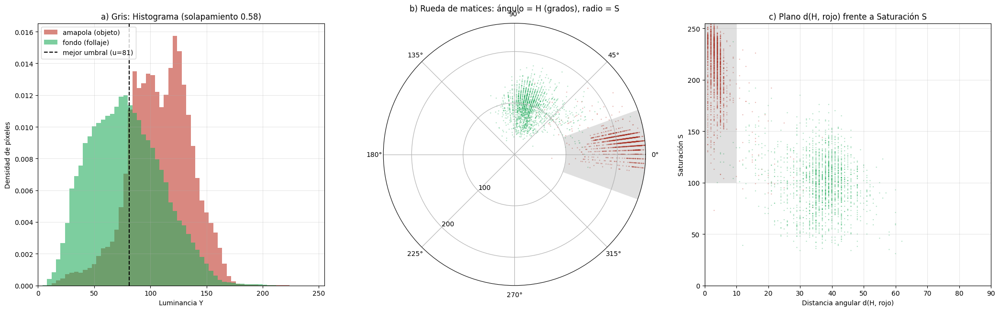

                                  Fondo dentro de la máscara  Flor fuera de la máscara
Gris (u = 81)                                          42.4 %                    14.4 %
HSV (ancho 10, S>=100, V>=40)                           0.8 %                     2.4 %


In [ ]:
from matplotlib.lines import Line2D

# --- Muestra de píxeles: 2000 de flor y 2000 de fondo, los mismos en todas las nubes ---
N_MUESTRA = 2000
rng = np.random.default_rng(42)
MUESTRA = np.concatenate([rng.choice(np.flatnonzero(gt), N_MUESTRA, replace=False),
                          rng.choice(np.flatnonzero(~gt), N_MUESTRA, replace=False)])
ORDEN = rng.permutation(2 * N_MUESTRA)   # orden de dibujo aleatorio: ninguna clase tapa a la otra
COLORES_MUESTRA = np.array(['#c0392b'] * N_MUESTRA + ['#27ae60'] * N_MUESTRA)
LEYENDA_CLASES = [Line2D([], [], marker='o', ls='', color='#c0392b', label='amapola'),
                  Line2D([], [], marker='o', ls='', color='#27ae60', label='fondo')]


def nube(ax, x, y):
    # Nube de los píxeles muestreados; x e y son canales completos (alto x ancho)
    xs, ys = x.reshape(-1)[MUESTRA], y.reshape(-1)[MUESTRA]
    ax.scatter(xs[ORDEN], ys[ORDEN], c=COLORES_MUESTRA[ORDEN], s=3, alpha=0.35, linewidths=0)


# Región de la máscara de HSV que se sombrea (valores elegidos en la sección 2.2)
ANCHO_NUBE, S_MIN_NUBE = 10, 100

fig = plt.figure(figsize=(21, 6.5))
ax_gris = fig.add_subplot(1, 3, 1)
ax_rueda = fig.add_subplot(1, 3, 2, projection='polar')
ax_dist = fig.add_subplot(1, 3, 3)

# a) Gris: Histograma de barras superpuestas para evitar solapamiento visual
ax_gris.hist(img_gris[gt], bins=64, range=(0, 256), density=True, alpha=0.6, color='#c0392b', label='amapola (objeto)')
ax_gris.hist(img_gris[~gt], bins=64, range=(0, 256), density=True, alpha=0.6, color='#27ae60', label='fondo (follaje)')
ax_gris.axvline(UMBRAL_GRIS_FIJO, color='k', ls='--', label=f'mejor umbral (u={UMBRAL_GRIS_FIJO})')
ax_gris.set_xlim(0, 255)
ax_gris.set_xlabel('Luminancia Y')
ax_gris.set_ylabel('Densidad de píxeles')
ax_gris.grid(alpha=0.3)
ax_gris.legend(loc='upper left')
ax_gris.set_title(f"a) Gris: Histograma (solapamiento {coef_solapamiento(img_gris, (0, 256)):.2f})")

# b) Rueda de matices: ángulo = H en grados reales, radio = S
nube(ax_rueda, np.radians(2.0 * canal_h), canal_s)
sector = np.radians(np.linspace(-2 * ANCHO_NUBE, 2 * ANCHO_NUBE, 50))
ax_rueda.fill_between(sector, S_MIN_NUBE, 255, color='k', alpha=0.12, lw=0)
ax_rueda.set_ylim(0, 255); ax_rueda.set_yticks([100, 200]); ax_rueda.set_rlabel_position(225)
ax_rueda.set_title("b) Rueda de matices: ángulo = H (grados), radio = S", pad=18)

# c) Distancia al rojo frente a S, con la región de la máscara
nube(ax_dist, dist_rojo, canal_s)
ax_dist.fill_between([0, ANCHO_NUBE], S_MIN_NUBE, 255, color='k', alpha=0.12, lw=0)
ax_dist.set_xlim(0, 90); ax_dist.set_ylim(0, 255)
ax_dist.set_xlabel('Distancia al color rojo en Matiz (Canal H)')
ax_dist.set_ylabel('Saturación de Color (Canal S)')
ax_dist.grid(alpha=0.3)
ax_dist.set_title("c) Dispersión: Distancia al rojo frente a Saturación")
plt.tight_layout(); plt.show()

# Píxeles de la muestra del lado equivocado de cada umbral
flor_m, fondo_m = slice(0, N_MUESTRA), slice(N_MUESTRA, 2 * N_MUESTRA)
en_gris = seg_gris_fijo(img_rgb).reshape(-1)[MUESTRA]
# Misma máscara que mascara_hsv (sección 2.2) con ancho 10, S >= 100 y V >= 40
m_nube =(dist_rojo <= ANCHO_NUBE) & (canal_s >= S_MIN_NUBE) & (canal_v >= 40)
en_hsv = m_nube.reshape(-1)[MUESTRA]
print(f"{'':32s} {'Fondo dentro de la máscara':>27s} {'Flor fuera de la máscara':>25s}")
print(f"{'Gris (u = ' + str(UMBRAL_GRIS_FIJO) + ')':32s} {100 * en_gris[fondo_m].mean():26.1f} % {100 * (~en_gris[flor_m]).mean():23.1f} %")
print(f"{'HSV (ancho 10, S>=100, V>=40)':32s} {100 * en_hsv[fondo_m].mean():26.1f} % {100 * (~en_hsv[flor_m]).mean():23.1f} %")

**Lectura de los gráficos:**

* **a) Gris.** Los dos histogramas se superponen en buena parte del rango de $Y$ (aproximadamente entre 50 y 140) y no hay un valle entre ellos. Cualquier umbral deja mucho rojo de un lado y mucho verde del otro: es lo que significa un solapamiento de 0.58. Con el mejor umbral posible, sobre la muestra de 2000 píxeles por clase (tabla impresa debajo de la figura), el 42 % del fondo queda dentro de la máscara y el 14 % de la flor queda afuera.
* **b) Rueda.** La flor forma un solo grupo alrededor de 0°, que **cruza el corte** entre 358° y 0°: en la rueda es un grupo continuo, pero en el eje lineal de 0 a 179 queda partido en los dos extremos. Por eso la media de H crudo cae lejos del rojo y la razón de Fisher ingenua da casi cero. El follaje queda en otro sector, separado por un hueco sin puntos. La flor además está casi toda lejos del centro (muy saturada) y el follaje más cerca: S ayuda, pero lo que separa es el ángulo.
* **c) Desenrollado.** Con la distancia angular, la flor queda en una columna pegada a 0 y el follaje más a la derecha. La región sombreada contiene casi toda la flor y casi nada de fondo: menos del 1 % del fondo entra en la máscara de HSV y queda afuera el 2 % de la flor.

### 2.2. Umbralización interactiva en HSV

* **Centro H / Ancho H**: el umbral principal (distancia angular al matiz).
* **Rango S**: descarta píxeles poco saturados, donde el matiz es inestable o indefinido (grises, blancos, reflejos).
* **Rango V**: descarta píxeles muy oscuros, donde H y S son ruido numérico.

In [ ]:
def mascara_hsv(img_hsv_, centro_h, ancho_h, rango_s, rango_v):
    h, s, v = cv2.split(img_hsv_)
    m_h = distancia_matiz(h, centro_h) <= ancho_h
    m_s = (s >= rango_s[0]) & (s <= rango_s[1])
    m_v = (v >= rango_v[0]) & (v <= rango_v[1])
    return m_h, m_h & m_s & m_v


def plot_umbral_hsv(centro_h, ancho_h, rango_s, rango_v):
    m_h, m_final = mascara_hsv(img_hsv, centro_h, ancho_h, rango_s, rango_v)
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    axes[0].imshow(distancia_matiz(canal_h, centro_h), cmap='viridis_r', vmin=0, vmax=90)
    axes[0].contour(m_h, levels=[0.5], colors='r', linewidths=1)
    axes[0].set_title(f"d(H, {centro_h}) y borde de d <= {ancho_h}")
    axes[1].imshow(superponer(img_rgb, m_h)); axes[1].set_title(f"Sólo H: {texto_metricas(m_h)}")
    axes[2].imshow(superponer(img_rgb, m_final)); axes[2].set_title(f"H + S + V: {texto_metricas(m_final)}")
    for ax in axes: ax.axis('off')
    plt.show()


centro_h_slider = widgets.IntSlider(value=0, min=0, max=179, step=1, description='Centro H')
ancho_h_slider = widgets.IntSlider(value=10, min=0, max=90, step=1, description='Ancho H')
s_slider = widgets.IntRangeSlider(value=[100, 255], min=0, max=255, step=1, description='Rango S')
v_slider = widgets.IntRangeSlider(value=[40, 255], min=0, max=255, step=1, description='Rango V')

interactive_hsv = interactive(plot_umbral_hsv, centro_h=centro_h_slider, ancho_h=ancho_h_slider,
                              rango_s=s_slider, rango_v=v_slider)
interactive_hsv.children[-1].layout.height = '450px'
display(interactive_hsv)

interactive(children=(IntSlider(value=0, description='Centro H', max=179), IntSlider(value=10, description='An…

**Bitácora del ensayo interactivo en HSV:**

* Con **sólo H** (centro 0) ya se obtiene la flor casi entera. El resultado es muy estable: con anchos entre 6 y 14 el IoU se mantiene en una meseta de ~0.95-0.96, porque entre el rojo de la flor y el verde del follaje hay un "hueco" de más de 50° en el círculo cromático (contrastar con la curva de grises, que no tiene ningún máximo marcado). Se elige **ancho = 10**, el centro de la meseta: deja margen hacia los dos lados.
* Si se abre mucho el ancho (> ~20) empiezan a entrar píxeles del fondo con matices anaranjados/amarillentos y el IoU baja de a poco (ancho 24 → ~0.85).
* Lo que falta son el **centro de la flor** (cápsula verde-amarillenta y estambres negros) y algunos píxeles del borde. Ningún umbral sobre "rojo" los recupera; son huecos que hay que rellenar después (sección 3). Que la referencia los incluya es una decisión: "la flor" como objeto completo, no "los píxeles rojos".
* **S y V casi no cambian nada en esta imagen.** El fondo es follaje verde, que ya queda afuera por H; no hay grises, blancos ni negros grandes con matiz rojizo "por casualidad". Subir V a ~80 no mejora la precisión (ya es ≈ 0.99) y baja el recall a ≈ 0.97: empieza a recortar las zonas sombreadas de los pétalos. Es una diferencia con escenas de fondo poco saturado (madera, pared, asfalto), donde el umbral en S sí es imprescindible.

Barrido rápido del ancho y efecto de cada canal, para apoyar lo anterior con números:

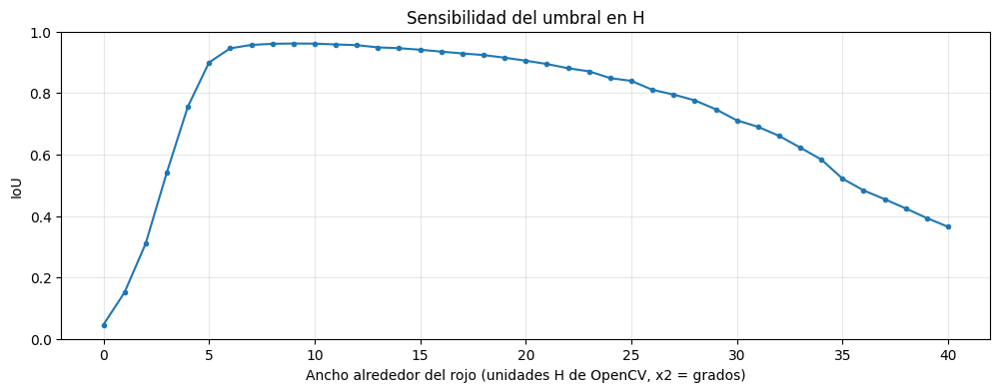

Gris (mejor umbral posible): IoU=0.411 | P=0.44 | R=0.85
Sólo H:                      IoU=0.961 | P=0.98 | R=0.98
H + S:                       IoU=0.962 | P=0.98 | R=0.98
H + S + V:                   IoU=0.962 | P=0.99 | R=0.98


In [ ]:
anchos = np.arange(0, 41)
iou_ancho = [metricas(distancia_matiz(canal_h, 0) <= a)['IoU'] for a in anchos]

plt.figure(figsize=(12, 4))
plt.plot(anchos, iou_ancho, marker='.')
plt.xlabel('Ancho alrededor del rojo (unidades H de OpenCV, x2 = grados)'); plt.ylabel('IoU')
plt.title('Sensibilidad del umbral en H'); plt.ylim(0, 1); plt.grid(alpha=0.3)
plt.show()

PARAMS_HSV = dict(centro_h=0, ancho_h=10, rango_s=(100, 255), rango_v=(40, 255))
m_solo_h, m_hsv = mascara_hsv(img_hsv, **PARAMS_HSV)
m_hs = m_solo_h & (canal_s >= PARAMS_HSV['rango_s'][0])

print(f"Gris (mejor umbral posible): {texto_metricas(mascara_gris_mejor)}")
print(f"Sólo H:                      {texto_metricas(m_solo_h)}")
print(f"H + S:                       {texto_metricas(m_hs)}")
print(f"H + S + V:                   {texto_metricas(m_hsv)}")

## 3. ¿La máscara queda limpia? Refinamiento morfológico

La máscara de HSV no es un blob sólido: tiene **huecos** (el centro de la flor, los estambres, puntitos oscuros sobre los pétalos) y algunos **píxeles sueltos** fuera del objeto. Se cuantifica con el número de componentes conexas y de huecos, y se prueba una limpieza clásica con morfología matemática:

1. **Apertura** (erosión + dilatación): elimina puntos sueltos más chicos que el elemento estructurante.
2. **Cierre** (dilatación + erosión): cierra huecos chicos y grietas.
3. **Mayor componente conexa**: nos quedamos con el blob más grande (sabemos que hay un solo objeto).
4. **Relleno de huecos**: se rellena el contorno externo; resuelve huecos grandes (el centro de la flor) que el cierre no alcanza.

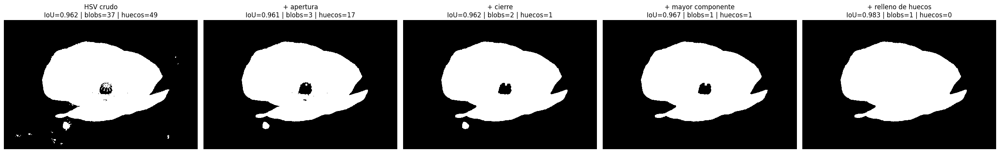

HSV crudo              IoU=0.962 | P=0.99 | R=0.98 | blobs=  37 | huecos=  49
+ apertura             IoU=0.961 | P=0.99 | R=0.97 | blobs=   3 | huecos=  17
+ cierre               IoU=0.962 | P=0.99 | R=0.97 | blobs=   2 | huecos=   1
+ mayor componente     IoU=0.967 | P=1.00 | R=0.97 | blobs=   1 | huecos=   1
+ relleno de huecos    IoU=0.983 | P=1.00 | R=0.99 | blobs=   1 | huecos=   0


In [ ]:
def contar_componentes(mascara):
    n, _ = cv2.connectedComponents(mascara.astype(np.uint8))
    return n - 1  # sin contar el fondo


def contar_huecos(mascara):
    """Componentes del fondo que no tocan el borde de la imagen (= huecos dentro de objetos)."""
    n, etiquetas = cv2.connectedComponents((~mascara.astype(bool)).astype(np.uint8))
    borde = np.unique(np.concatenate([etiquetas[0], etiquetas[-1], etiquetas[:, 0], etiquetas[:, -1]]))
    return len(set(range(1, n)) - set(borde))


def mayor_componente(mascara):
    n, etiquetas, stats, _ = cv2.connectedComponentsWithStats(mascara.astype(np.uint8))
    if n <= 1:
        return mascara.astype(bool)
    return etiquetas == 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])


def rellenar_huecos(mascara):
    contornos, _ = cv2.findContours(mascara.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    salida = np.zeros(mascara.shape, np.uint8)
    cv2.drawContours(salida, contornos, -1, 1, thickness=-1)
    return salida.astype(bool)


kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
m_apertura = cv2.morphologyEx(m_hsv.astype(np.uint8), cv2.MORPH_OPEN, kernel).astype(bool)
m_cierre = cv2.morphologyEx(m_apertura.astype(np.uint8), cv2.MORPH_CLOSE, kernel).astype(bool)
m_mayor = mayor_componente(m_cierre)
m_final = rellenar_huecos(m_mayor)

pasos = [('HSV crudo', m_hsv), ('+ apertura', m_apertura), ('+ cierre', m_cierre),
         ('+ mayor componente', m_mayor), ('+ relleno de huecos', m_final)]

fig, axes = plt.subplots(1, len(pasos), figsize=(26, 4.5))
for ax, (nombre, m) in zip(axes, pasos):
    ax.imshow(m, cmap='gray')
    ax.set_title(f"{nombre}\nIoU={metricas(m)['IoU']:.3f} | blobs={contar_componentes(m)} | huecos={contar_huecos(m)}")
    ax.axis('off')
plt.tight_layout(); plt.show()

for nombre, m in pasos:
    print(f"{nombre:22s} {texto_metricas(m)} | blobs={contar_componentes(m):4d} | huecos={contar_huecos(m):4d}")

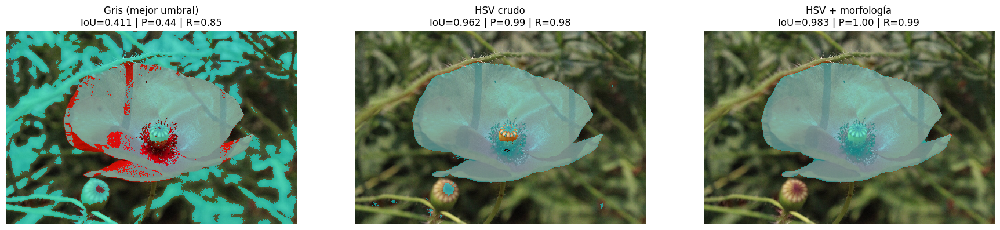

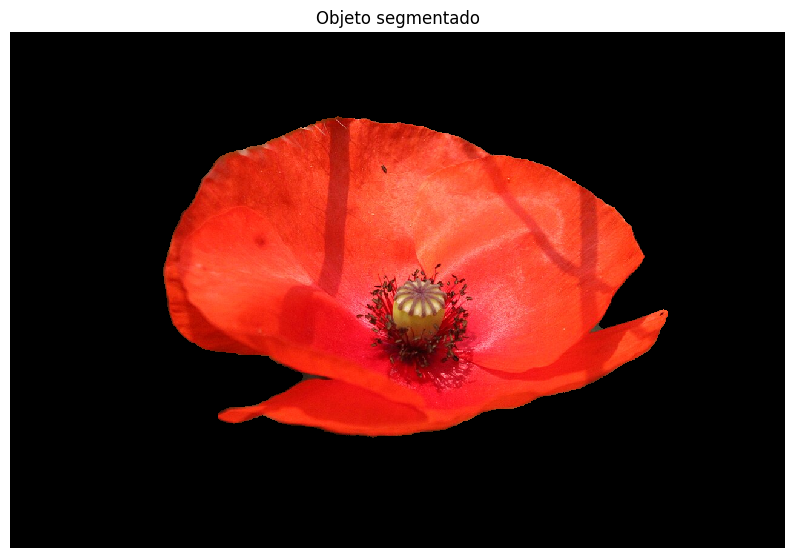

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 5.5))
axes[0].imshow(superponer(img_rgb, mascara_gris_mejor)); axes[0].set_title(f"Gris (mejor umbral)\n{texto_metricas(mascara_gris_mejor)}")
axes[1].imshow(superponer(img_rgb, m_hsv)); axes[1].set_title(f"HSV crudo\n{texto_metricas(m_hsv)}")
axes[2].imshow(superponer(img_rgb, m_final)); axes[2].set_title(f"HSV + morfología\n{texto_metricas(m_final)}")
for ax in axes: ax.axis('off')
plt.show()

# Aplicar la máscara a los tres canales de la imagen original
objeto_segmentado = cv2.bitwise_and(img_rgb, img_rgb, mask=m_final.astype(np.uint8))
plt.figure(figsize=(10, 7)); plt.imshow(objeto_segmentado); plt.title("Objeto segmentado"); plt.axis('off'); plt.show()

## 4. Robustez frente a cambios de iluminación

La pregunta "¿es robusta la técnica?" se puede contestar con un experimento en vez de con una opinión: se **congelan los umbrales** elegidos sobre la imagen original y se aplican, sin tocarlos, a versiones de la misma imagen con la iluminación modificada:

* **Oscura ×0.5 / Clara ×1.4**: cambio de intensidad global (otra hora del día, nubes, otra exposición de la cámara).
* **Gradiente**: luz desigual de izquierda a derecha (sombra de un árbol, una lámpara que se quemó de un lado).
* **Luz cálida / fría**: cambio de **temperatura de color** de la fuente (atardecer, LED frío, día nublado). Esto ya no es un cambio de intensidad sino de *color* de la luz.

Condición           Gris (u fijo)  HSV (fijo)
Original                    0.411       0.962
Oscura x0.5                 0.011       0.958
Clara x1.4                  0.352       0.939
Gradiente lateral           0.324       0.963
Luz cálida                  0.430       0.962
Luz fría                    0.329       0.933


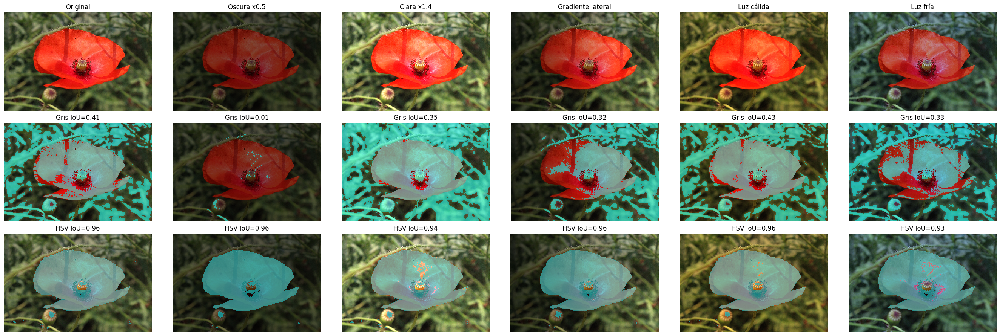

In [ ]:
f = img_rgb.astype(np.float32)
gradiente = np.linspace(0.35, 1.3, ancho).reshape(1, ancho, 1)
condiciones = {
    'Original':          img_rgb,
    'Oscura x0.5':       np.clip(f * 0.5, 0, 255).astype(np.uint8),
    'Clara x1.4':        np.clip(f * 1.4, 0, 255).astype(np.uint8),
    'Gradiente lateral': np.clip(f * gradiente, 0, 255).astype(np.uint8),
    'Luz cálida':        np.clip(f * np.array([1.15, 1.0, 0.7]), 0, 255).astype(np.uint8),
    'Luz fría':          np.clip(f * np.array([0.75, 0.95, 1.25]), 0, 255).astype(np.uint8),
}


def seg_hsv_fijo(img, ancho_h=PARAMS_HSV['ancho_h']):
    params = dict(PARAMS_HSV, ancho_h=ancho_h)
    return mascara_hsv(cv2.cvtColor(img, cv2.COLOR_RGB2HSV), **params)[1]


fig, axes = plt.subplots(3, len(condiciones), figsize=(4.5 * len(condiciones), 9))
print(f"{'Condición':18s} {'Gris (u fijo)':>14s} {'HSV (fijo)':>11s}")
for j, (nombre, img) in enumerate(condiciones.items()):
    mg, mh = seg_gris_fijo(img), seg_hsv_fijo(img)
    axes[0, j].imshow(img); axes[0, j].set_title(nombre)
    axes[1, j].imshow(superponer(img, mg)); axes[1, j].set_title(f"Gris IoU={metricas(mg)['IoU']:.2f}")
    axes[2, j].imshow(superponer(img, mh)); axes[2, j].set_title(f"HSV IoU={metricas(mh)['IoU']:.2f}")
    print(f"{nombre:18s} {metricas(mg)['IoU']:14.3f} {metricas(mh)['IoU']:11.3f}")
for ax in axes.ravel(): ax.axis('off')
plt.tight_layout(); plt.show()

In [ ]:
# Efecto del ancho de H sobre la robustez (trade-off precisión / tolerancia)
print(f"{'Condición':18s} " + " ".join(f"{'ancho ' + str(a):>9s}" for a in (6, 8, 10, 12, 14)))
for nombre, img in condiciones.items():
    print(f"{nombre:18s} " + " ".join(f"{metricas(seg_hsv_fijo(img, a))['IoU']:9.3f}" for a in (6, 8, 10, 12, 14)))

Condición            ancho 6   ancho 8  ancho 10  ancho 12  ancho 14
Original               0.946     0.962     0.962     0.958     0.952
Oscura x0.5            0.940     0.956     0.958     0.958     0.955
Clara x1.4             0.730     0.890     0.939     0.948     0.943
Gradiente lateral      0.943     0.962     0.963     0.962     0.957
Luz cálida             0.793     0.926     0.962     0.962     0.954
Luz fría               0.894     0.919     0.933     0.941     0.945


**Lectura.** El umbral de grises, que ya era malo, colapsa con cualquier cambio de intensidad: con la imagen oscurecida, el umbral fijo deja afuera prácticamente toda la flor (IoU ≈ 0.01). Un umbral sobre brillo está, por definición, atado al nivel de iluminación.

El de HSV se mantiene en ≈ 0.96 ante el oscurecimiento y el gradiente, porque H es invariante a escalar (R, G, B) por un mismo factor. Pero aparecen dos casos que **no** son invariantes:

* **Clara ×1.4**: los pétalos ya tenían R cerca de 255; al multiplicar, R se **satura (clipping)** en 255 mientras G y B siguen creciendo, la proporción entre canales cambia y el matiz se corre hacia el naranja. La invariancia de H vale para la luz, pero no sobrevive a un sensor saturado.
* **Luz fría**: una luz azulada sí corre el matiz de los pétalos (hacia el magenta) y parte de los píxeles sale del rango.

La segunda tabla muestra el efecto del ancho: en la imagen original todos los anchos de la meseta dan prácticamente lo mismo (≈ 0.95-0.96), pero fuera de la condición de calibración la diferencia es grande. Con ancho 6, la sobreexposición cae a ≈ 0.73 y la luz cálida (que corre el rojo hacia el naranja) a ≈ 0.79; con 10-12 ambas quedan en ≈ 0.94-0.96. **Elegir el umbral mirando sólo la imagen de calibración no alcanza**: dos umbrales igual de buenos ahí pueden comportarse muy distinto cuando cambia el entorno. Acá conviene un ancho generoso porque el fondo (verde) está lejos del rojo en el círculo cromático; con un fondo anaranjado no habría ese margen.

## 5. ¿Otro espacio de color podría ser mejor?

El objetivo es aislar un **rojo** de un **verde**. Dos candidatos separan luminancia de crominancia y además tienen un eje que es, literalmente, "rojo":

* **CIE L\*a\*b\***, canal **a\*** (eje verde ↔ rojo/magenta): para este problema es el eje exacto.
* **YCrCb**, canal **Cr** (diferencia de rojo, R − Y).

Ventaja clave sobre H: son ejes **lineales**, sin empalme 0/179, así que Otsu se puede aplicar directo y elegir el umbral **automáticamente**. Se comparan todos los canales candidatos con las mismas métricas:

In [ ]:
img_lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
img_ycc = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2YCrCb)
canal_a = img_lab[..., 1]
canal_cr = img_ycc[..., 1]

candidatos = {
    'Gris (Y)':       (img_gris, (0, 256)),
    'V (HSV)':        (canal_v, (0, 256)),
    'S (HSV)':        (canal_s, (0, 256)),
    'd(H, rojo)':     (dist_rojo, (0, 90)),
    'a* (Lab)':       (canal_a, (0, 256)),
    'Cr (YCrCb)':     (canal_cr, (0, 256)),
}

print(f"{'Canal':14s} {'Solapamiento':>13s} {'Fisher':>8s} {'IoU Otsu':>9s}")
for nombre, (canal, rango) in candidatos.items():
    t, _ = cv2.threshold(canal, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # Se toma el lado de Otsu que corresponde al objeto (en d(H,rojo) el objeto es el lado bajo)
    m = canal > t
    if metricas(~m)['IoU'] > metricas(m)['IoU']:
        m = ~m
    print(f"{nombre:14s} {coef_solapamiento(canal, rango):13.3f} {razon_fisher(canal):8.2f} {metricas(m)['IoU']:9.3f}")

Canal           Solapamiento   Fisher  IoU Otsu
Gris (Y)               0.585     0.51     0.406
V (HSV)                0.081     8.19     0.901
S (HSV)                0.058     8.35     0.917
d(H, rojo)             0.029    15.82     0.895
a* (Lab)               0.022    25.74     0.958
Cr (YCrCb)             0.021    21.19     0.944


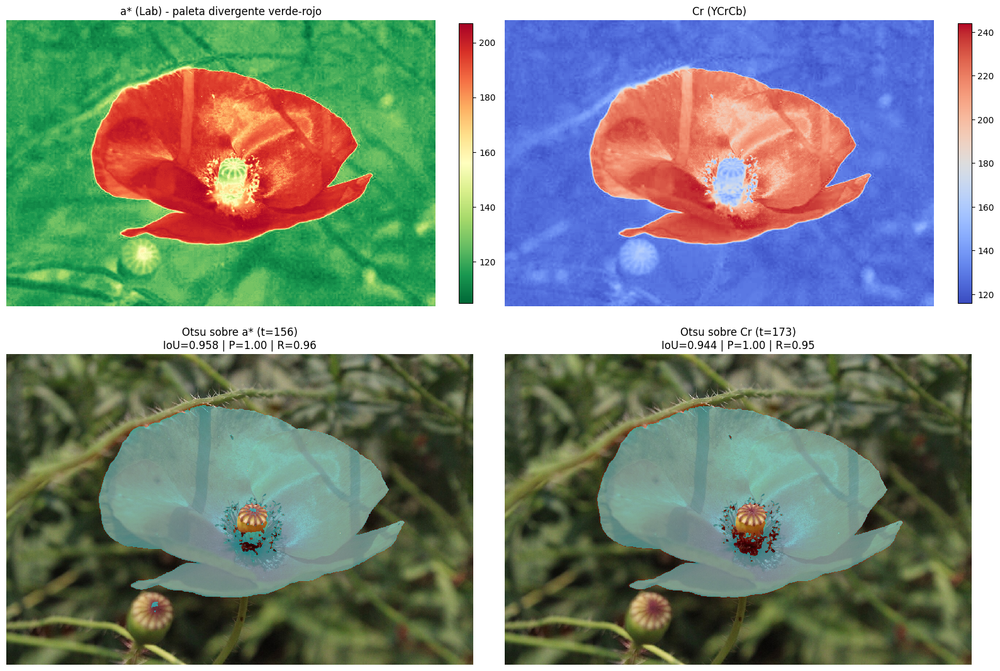

In [ ]:
t_a, _ = cv2.threshold(canal_a, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
t_cr, _ = cv2.threshold(canal_cr, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
im = axes[0, 0].imshow(canal_a, cmap='RdYlGn_r'); axes[0, 0].set_title("a* (Lab) - paleta divergente verde-rojo")
fig.colorbar(im, ax=axes[0, 0], fraction=0.03)
im = axes[0, 1].imshow(canal_cr, cmap='coolwarm'); axes[0, 1].set_title("Cr (YCrCb)")
fig.colorbar(im, ax=axes[0, 1], fraction=0.03)
axes[1, 0].imshow(superponer(img_rgb, canal_a > t_a)); axes[1, 0].set_title(f"Otsu sobre a* (t={t_a:.0f})\n{texto_metricas(canal_a > t_a)}")
axes[1, 1].imshow(superponer(img_rgb, canal_cr > t_cr)); axes[1, 1].set_title(f"Otsu sobre Cr (t={t_cr:.0f})\n{texto_metricas(canal_cr > t_cr)}")
for ax in axes.ravel(): ax.axis('off')
plt.tight_layout(); plt.show()

Nubes de píxeles en el plano de cromaticidad de cada espacio, con las mismas muestras de la sección 2.1.1. Se agrega RGB (plano R–G) como referencia. Las líneas son los umbrales de Otsu.

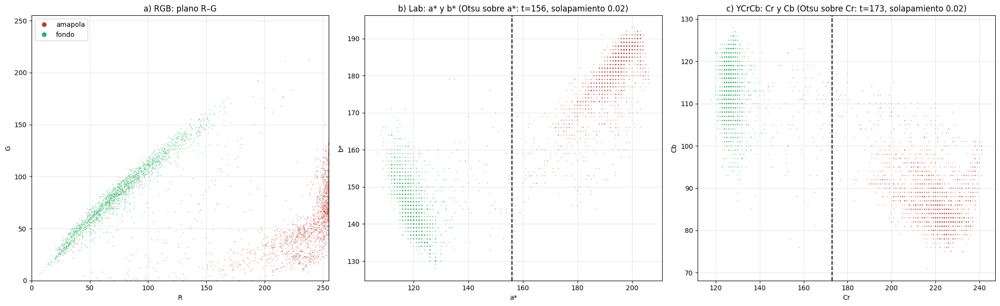

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6.5))
nube(axes[0], img_rgb[..., 0], img_rgb[..., 1])
axes[0].set_xlim(0, 255); axes[0].set_ylim(0, 255)
axes[0].set_xlabel('R'); axes[0].set_ylabel('G'); axes[0].set_title('a) RGB: plano R–G')
axes[0].legend(handles=LEYENDA_CLASES, loc='upper left')

nube(axes[1], canal_a, img_lab[..., 2])
axes[1].axvline(t_a, color='k', ls='--')
axes[1].set_xlabel('a*'); axes[1].set_ylabel('b*')
axes[1].set_title(f"b) Lab: a* y b* (Otsu sobre a*: t={t_a:.0f}, solapamiento {coef_solapamiento(canal_a, (0, 256)):.2f})")

nube(axes[2], canal_cr, img_ycc[..., 2])
axes[2].axvline(t_cr, color='k', ls='--')
axes[2].set_xlabel('Cr'); axes[2].set_ylabel('Cb')
axes[2].set_title(f"c) YCrCb: Cr y Cb (Otsu sobre Cr: t={t_cr:.0f}, solapamiento {coef_solapamiento(canal_cr, (0, 256)):.2f})")
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Lectura de las nubes:**

* **a) RGB.** La flor forma una banda con R alto (muchos puntos en R = 255, por la saturación del sensor) y G bajo; el follaje queda cerca de la diagonal R ≈ G. En RGB las clases ya están separadas, pero en una **dirección oblicua**, y un píxel más oscuro se mueve hacia el origen. La conversión a gris proyecta la nube sobre una dirección en la que flor y fondo caen en los mismos valores, y por eso las mezcla.
* **b) Lab.** Las dos nubes quedan a cada lado de una línea vertical: alcanza con un umbral sobre a\*, y Otsu lo encuentra solo. El follaje está a la izquierda de 128 (verde) y la flor muy a la derecha (rojo).
* **c) YCrCb.** Mismo comportamiento con Cr; las nubes quedan algo más cerca entre sí que en a\*, coherente con su razón de Fisher un poco menor.

Robustez de a\* con umbral **fijo** vs con umbral **Otsu recalculado** en cada condición (comparado con HSV fijo):

In [ ]:
UMBRAL_A_FIJO = t_a

print(f"{'Condición':18s} {'HSV fijo':>9s} {'a* fijo':>8s} {'a* Otsu':>8s}")
for nombre, img in condiciones.items():
    a = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)[..., 1]
    t, _ = cv2.threshold(a, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    print(f"{nombre:18s} {metricas(seg_hsv_fijo(img))['IoU']:9.3f} "
          f"{metricas(a > UMBRAL_A_FIJO)['IoU']:8.3f} {metricas(a > t)['IoU']:8.3f}")

Condición           HSV fijo  a* fijo  a* Otsu
Original               0.962    0.958    0.958
Oscura x0.5            0.958    0.894    0.955
Clara x1.4             0.939    0.942    0.954
Gradiente lateral      0.963    0.951    0.959
Luz cálida             0.962    0.967    0.963
Luz fría               0.933    0.928    0.958


**Lectura.**

* **a\* y Cr** separan **mejor** que H: solapamiento algo menor (~0.02 contra ~0.03) y Fisher bastante mayor (≈ 26 y ≈ 21 contra ≈ 16). Tienen dos ventajas prácticas: no hay que manejar la circularidad, y como su histograma sí es bimodal *objeto vs fondo*, **Otsu encuentra solo un buen umbral** (IoU ≈ 0.96 sin tocar nada a mano, cosa que en grises fallaba). Recalcular Otsu en cada imagen hace al método adaptativo: es el más estable de la tabla.
* Pero a\* no es invariante a la intensidad: es una diferencia de color cuya magnitud crece con el brillo, así que con un **umbral fijo** la versión oscura se degrada (≈ 0.89) mientras H no se mueve (≈ 0.96). Es un *trade-off* real: **H** = invariancia a la intensidad con umbral fijo; **a\*/Cr** = eje lineal, mayor separabilidad y umbral automático.
* **Dato llamativo: V separa mucho mejor que Y** (Otsu ≈ 0.90 contra ≈ 0.41), aunque los dos "miden brillo". La razón: V = max(R, G, B), que para un rojo saturado vale R ≈ 255, mientras que Y pondera R sólo con 0.299. Es decir, V no es luminancia perceptual: es un canal que, para colores saturados, sigue reteniendo información de croma. Igual no conviene usarlo como criterio principal: depende de la iluminación tanto como Y, y fallaría con cualquier objeto claro de otro color.

---

## 6. Preguntas y análisis

### ¿Se logró segmentar el objeto de manera efectiva en la escala de grises? ¿Qué problemas aparecieron?

**No.** Con el mejor umbral global posible (elegido con el oráculo, sobre los 256 valores y en ambos sentidos) el IoU llega a ≈ 0.41, con una precisión de ≈ 0.44: más de la mitad de lo segmentado es follaje. Otsu, que sería la elección automática, cae prácticamente en el mismo punto. Probar "a zero" o una banda doble no cambia el resultado de fondo.

Problemas concretos:

1. **Objeto y fondo con brillos similares.** Es la pista del enunciado y se confirma con números: los histogramas de luminancia de flor y fondo comparten ≈ 58 % de su masa. Un rojo saturado tiene una luminancia media (Y = 0.299R + 0.587G + 0.114B, y los pétalos tienen G y B bajos), la misma que el follaje verde iluminado. Al pasar a grises, **dos colores muy distintos con igual Y se vuelven indistinguibles**: la conversión es una proyección de 3D a 1D que descarta justo la dimensión que los separaba.
2. **El objeto no tiene un brillo uniforme.** La sombra del tallo sobre los pétalos, los pliegues y el centro oscuro hacen que la propia flor abarque un rango amplio de grises, que se superpone con el fondo.
3. **El fondo tampoco es uniforme.** El follaje desenfocado tiene zonas claras (hojas al sol, tallos) y oscuras (sombra); las claras caen en el rango de la flor.
4. **Otsu no ayuda.** Otsu maximiza la varianza entre clases suponiendo un histograma bimodal. Encuentra los modos "escena oscura" y "escena clara", que no corresponden a objeto/fondo. Que coincida con el óptimo del oráculo muestra que el límite es del dominio, no del método.

### ¿Por qué la umbralización en el canal H es significativamente más robusta y efectiva? (desacoplamiento luminancia/crominancia)

Porque HSV **separa en ejes distintos** dos cosas que en RGB y en grises están mezcladas: *qué color es* (H, y su pureza S) y *cuánta luz llega* (V). La conversión calcula H a partir de las **diferencias relativas** entre canales:

* Si la iluminación escala los tres canales por un factor k (sombra, nube, otra exposición, otra hora del día), las diferencias y el máximo escalan igual y su cociente, **H, no cambia**. Todo el efecto de la iluminación cae en V (S, que también es un cociente, tampoco cambia).
* Por eso los pétalos al sol y los pétalos bajo la sombra del tallo tienen el mismo H ≈ 0-5, aunque su gris sea muy distinto. Lo que en grises era un rango ancho y solapado, en H es un pico angosto, separado por más de 50° del pico del follaje (H ≈ 30-50).

Las métricas lo confirman: el solapamiento objeto/fondo baja de ≈ 0.58 (gris) a ≈ 0.03 (distancia angular al rojo), la razón de Fisher se multiplica por ≈ 30, el IoU sube de ≈ 0.41 a ≈ 0.96 sólo con H, y el umbral es **muy poco sensible** (anchos entre 6 y 14 dan IoU de 0.95 a 0.96). En el experimento de la sección 4, con umbrales congelados, HSV se mantiene en ≈ 0.93-0.96 en todas las condiciones mientras el gris cae hasta ≈ 0.01.

Dos limitaciones que aparecieron y que conviene tener presentes:

* **Circularidad**: el rojo está en el empalme 0/179. Hay que usar dos rangos o, como acá, la distancia angular. Un análisis estadístico ingenuo sobre H crudo (Fisher ≈ 0.10, peor que el gris) diría erróneamente que H no sirve.
* **Singularidades**: en blancos, grises y negros H está indefinido o es ruido, y si el sensor se satura (un canal clipeado en 255) H se corre. Por eso el centro oscuro de la flor queda como hueco, y por eso la versión sobreexpuesta pierde algo de IoU.

### ¿Otro espacio de color podría ser mejor para el objeto/imagen seleccionada?

**Sí, y se midió (sección 5).** Para separar rojo de verde, el canal **a\*** de CIE L\*a\*b\* es casi una definición del problema: es el eje verde ↔ rojo. Junto con **Cr** de YCrCb, separa mejor que H (Fisher ≈ 26 y ≈ 21 contra ≈ 16, solapamiento ≈ 0.02 contra ≈ 0.03). Además:

* son ejes **lineales**: no hay empalme 0/179 ni hace falta la distancia angular;
* su histograma es bimodal *objeto/fondo*, así que **Otsu elige solo el umbral** (IoU ≈ 0.96 sin ajustar nada a mano), y recalculado por imagen resulta el método más estable ante todos los cambios de iluminación probados.

La contra es que a\*/Cr **no son invariantes a la intensidad** (son diferencias, no cocientes): con un umbral fijo, la versión oscura ×0.5 baja a IoU ≈ 0.89, cuando H se mantiene en ≈ 0.96. La elección depende del escenario: si se quiere un umbral fijo calibrado una vez bajo iluminación muy variable en intensidad, H; si se puede usar un umbral adaptativo (Otsu por imagen), a\* es más simple y más separable. Para otros colores (por ejemplo, un objeto azul sobre un fondo amarillo) el eje que convendría sería b\* o Cb: **no hay un espacio ganador universal**, se mide en cada caso.

### Escenario práctico donde HSV supera a la escala de grises. ¿Es robusta o hay que ajustarla?

**Escenario: robot de cosecha o conteo de frutos en invernadero** (agroindustria). Se quiere detectar tomates o frutillas maduros (rojos) entre las hojas para guiar un brazo de cosecha o estimar rendimiento. Es exactamente la situación de esta imagen: objeto rojo sobre follaje verde de luminancia parecida. En grises el fruto se confunde con las hojas iluminadas; además, un fruto verde (no maduro) y uno rojo pueden tener la misma luminancia, así que ni siquiera se podría clasificar la madurez. Con un umbral en H (o en a\*) la discriminación rojo/verde es directa e independiente de las sombras de las hojas. Otros ejemplos del mismo tipo: **histopatología** (tinción hematoxilina-eosina: núcleos violáceos vs citoplasma rosado con brillos similares), **dermatología** (eritema o lesiones rojizas sobre piel), **detección de señales de tránsito**, **control de calidad de color** en una línea de envasado.

**¿Es robusta?** Depende de qué cambia en el entorno, y el experimento de la sección 4 permite responderlo por partes:

* **Cambios de intensidad** (hora del día, nubes, sombras de las plantas, exposición de la cámara, una lámpara de varias que se quema, gradientes de luz): H es **robusto**; con los umbrales congelados el IoU prácticamente no se movió.
* **Cambios en el color de la luz** (amanecer/atardecer, día nublado más azulado, reemplazo de lámparas por LED de otra temperatura, luces de cultivo violetas/rosadas en invernaderos): H **se corre** y el umbral fijo pierde precisión. Hay que compensar con **balance de blancos** (por ejemplo, una carta gris de referencia en el campo visual) o recalibrar. Las luces de cultivo LED rojo+azul son un caso extremo: ahí H de toda la escena se tiñe y el método directamente deja de funcionar sin corrección.
* **Sobreexposición o poca luz**: con canales saturados o V bajo, H se corre o se vuelve ruido; de noche, sin iluminación propia, el método no sirve.

En conclusión: es mucho más robusto que la escala de grises, pero **no es "configurar una vez y olvidarse"**. En una línea industrial se lo hace robusto controlando el entorno (iluminación propia, difusa y de temperatura de color fija, exposición fija) en vez de confiar sólo en la invariancia del espacio; en exteriores conviene un ancho de H generoso cuando el fondo lo permite, combinado con umbrales adaptativos (Otsu sobre a\*, por ejemplo) o recalibración periódica.

### ¿La máscara binaria queda "limpia"? ¿Qué operación se podría usar para limpiarla?

**No queda limpia.** La máscara cruda de HSV tiene un blob principal grande, pero también:

* **huecos** dentro de la flor (~50): el centro (cápsula verde-amarillenta y estambres negros, que no son rojos) y puntitos oscuros sobre los pétalos;
* **píxeles sueltos** fuera del objeto (~40 componentes conexas en total): manchas rojizas en el follaje, el borde del capullo, ruido en zonas oscuras.

La limpieza natural es **morfología matemática** (sección 3):

* **Apertura** (erosión → dilatación) para eliminar los puntos sueltos más chicos que el elemento estructurante.
* **Cierre** (dilatación → erosión) para cerrar huecos chicos y fisuras.
* **Análisis de componentes conexas** para quedarse con el blob de mayor área (o filtrar por área mínima si hay varios objetos).
* **Relleno de huecos** (rellenar el contorno externo, o *flood fill* desde el borde) para los huecos grandes, como el centro de la flor, que el cierre no alcanza sin deformar el contorno.

Con esa secuencia la máscara pasa a un único blob sin huecos y el IoU sube de ≈ 0.96 a ≈ 0.98. El tamaño del elemento estructurante es un parámetro más a justificar: muy chico no limpia, muy grande redondea el contorno y se come detalles (las puntas de los pétalos). Y hay una decisión de diseño detrás del relleno: si "el objeto" es la flor completa, rellenar el centro es correcto; si lo que interesa medir es **el área roja** (por ejemplo, para estimar madurez), no habría que rellenar.

### NOTA: ¿usar una paleta de color adecuada puede ayudar en este proceso?

**Sí, en dos momentos distintos:**

1. **Para entender el canal antes de umbralizar.** El canal H visto con `gray` es engañoso: el rojo de la flor aparece como una mezcla de negro (H≈0) y blanco (H≈179), un "ruido sal y pimienta" que no existe en el color real. Eso puede llevar a concluir que H es ruidoso sobre el objeto o a elegir un único rango que deja afuera parte de la flor. Una paleta **cíclica** (`hsv` o `twilight`, esta última además perceptualmente uniforme) respeta la topología del dato: los dos extremos se ven igual y la flor aparece homogénea.
2. **Para elegir el umbral.** Mostrar la distancia angular al rojo con una paleta secuencial perceptualmente uniforme (`viridis`) hace visible el "escalón" entre la flor y el follaje; con a\* conviene una **divergente** (`RdYlGn_r`) centrada en el neutro, porque el dato tiene un cero natural (a\* = 128 en OpenCV) y un signo con significado (verde vs rojo). Para este par de colores además coincide con la semántica: verde = follaje, rojo = flor.

Para la **máscara binaria** final, en cambio, alcanza con `gray` (o con superponerla en un color contrastante sobre la imagen original, acá cian, el complementario del rojo, que es lo que más ayuda a ver errores en el borde).

---

## 7. Bitácora de decisiones

| Bloque | Opción elegida | Por qué | Alternativa descartada y su problema | Criterio |
|---|---|---|---|---|
| Imagen | Amapola roja sobre follaje (Wikimedia Commons, CC0) | Un solo objeto de color distintivo; rojo y verde con luminancia parecida: pone a prueba la diferencia entre dominios | Una manzana anaranjada sobre madera (también de Commons): el objeto tiene el **mismo matiz** que el fondo, falla también en H (IoU ≈ 0.31), no sirve para comparar dominios | Métrica (solapamiento y barrido en gris y en H) |
| Referencia | Polígono trazado a mano sobre el borde de los pétalos (141 vértices) | Etiqueta independiente del color (evita circularidad) | Elipse o polígono grueso (34 vértices, primera versión): subestimaba el IoU de todos los métodos en ~0.05. Usar la máscara de HSV como verdad: razonamiento circular | Visual (superposición) |
| Grises | Binario, u ≈ 81 (mejor posible) | Es el máximo del barrido de IoU; la flor es algo más clara que el fondo | Binario invertido (segmenta el follaje en sombra), Otsu (u ≈ 86, mismo resultado), A Zero (misma máscara), banda (no mejora) | Métrica (barrido completo) |
| HSV - matiz | Distancia angular al rojo, ancho 10 | Respeta la circularidad; un solo parámetro; 10 es el centro de la meseta de IoU (6-14) y tolera mejor la sobreexposición y la luz fría | Un único rango `[0, a]`: pierde los píxeles con H ≈ 179. Ancho 6: casi igual en la original (0.95 contra 0.96), pero frágil (≈ 0.73 sobreexpuesta, ≈ 0.79 con luz cálida) | Métrica (barrido de ancho + robustez) |
| HSV - S | S >= 100 | Precaución estándar contra matices inestables | Sin S: en esta imagen da prácticamente lo mismo (el fondo es verde saturado, ya lo excluye H) | Métrica |
| HSV - V | V >= 40 | Descarta píxeles muy oscuros, donde H es ruido | V >= 80: algo más de precisión pero recorta la sombra del tallo sobre los pétalos | Visual + métrica |
| Limpieza | Apertura + cierre (elipse 15x15) + mayor componente + relleno | Un solo blob sin huecos | Sólo cierre: no llena el centro de la flor; kernel mayor: redondea las puntas de los pétalos | Métrica + conteo de blobs/huecos |
| Paleta H | `hsv` / `twilight` (cíclicas) | H es circular | `gray`: crea un falso borde negro/blanco dentro del rojo | Conceptual (topología del dato) |
| Otro espacio | a\* (Lab) con Otsu | Mayor Fisher, sin empalme, umbral automático | Cr: casi equivalente, apenas inferior. V: separa sorprendentemente bien acá (V = R en rojos saturados) pero depende de la iluminación. a\* con umbral fijo: frágil ante oscurecimiento | Métrica (solapamiento, Fisher, IoU, robustez) |